#### Dataset Link = https://www.kaggle.com/datasets/kartik2112/fraud-detection?select=fraudTrain.csv

## **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

## **Reading Main Data**

In [ ]:
df = pd.read_csv('fraudData.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [ ]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

## **Making Data**

In [ ]:
# Separate the fraud and non-fraud rows
fraud_df = df[df['is_fraud'] == 1]
non_fraud_df = df[df['is_fraud'] == 0]

# Randomly sample non-fraud rows to match the number of fraud rows
non_fraud_sampled = non_fraud_df.sample(n=len(fraud_df), random_state=42)

# Concatenate the balanced dataframes
data = pd.concat([fraud_df, non_fraud_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

data['is_fraud'].value_counts()

is_fraud
1    7506
0    7506
Name: count, dtype: int64

In [ ]:
data.to_csv("finalData.csv", index=False)

## **Info of Dataset**

In [ ]:
data = pd.read_csv("finalData.csv")
data.head()

In [ ]:
data.drop(columns=["Unnamed: 0"], axis=1, inplace=True)

*Description of numerical columns*

In [ ]:
data.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.501200e+04,15012.000000,15012.000000,15012.000000,15012.000000,1.501200e+04,1.501200e+04,15012.000000,15012.000000,15012.000000
mean,4.145026e+17,299.517998,48731.356248,38.620164,-90.275251,9.051075e+04,1.348818e+09,38.612480,-90.275455,0.500000
std,1.301544e+18,373.915804,27126.671123,5.128513,14.084930,3.035544e+05,1.332573e+07,5.168227,14.105491,0.500017
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325402e+09,19.041880,-166.550779,0.000000
25%,1.800400e+14,20.497500,25442.000000,34.778900,-96.983700,7.430000e+02,1.337471e+09,34.896843,-96.989761,0.000000
50%,3.523898e+15,89.545000,47869.000000,39.405500,-87.410100,2.526000e+03,1.348876e+09,39.403182,-87.360104,0.500000
75%,4.642255e+15,477.102500,72042.000000,42.015800,-80.128400,2.112500e+04,1.359844e+09,41.991035,-80.168734,1.000000
max,4.992346e+18,6337.250000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371813e+09,67.510267,-67.027467,1.000000


*Description of categorical columns*

In [ ]:
data.describe(exclude='number')

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,15012,15012,15012,15012,15012,15012,15012,15012,15012,15012,15012,15012
unique,15006,693,14,352,480,2,977,889,51,493,962,15012
top,2020-02-21 23:02:22,fraud_Kilback LLC,grocery_pos,Christopher,Smith,F,561 Little Plain Apt. 738,Warren,TX,Materials engineer,1981-08-29,c48f2efccb689f2daef9ebdb03e1edec
freq,2,72,2494,330,301,7835,38,57,1024,114,48,1


In [ ]:
cols = data.columns
for col in cols:
    print(f"{col} has min value {df[col].min()} and max value {df[col].max()}")
    print("*"*45)

trans_date_trans_time has min value 2019-01-01 00:00:18 and max value 2020-06-21 12:13:37
*********************************************
cc_num has min value 60416207185 and max value 4992346398065154184
*********************************************
merchant has min value fraud_Abbott-Rogahn and max value fraud_Zulauf LLC
*********************************************
category has min value entertainment and max value travel
*********************************************
amt has min value 1.0 and max value 28948.9
*********************************************
first has min value Aaron and max value Zachary
*********************************************
last has min value Abbott and max value Zuniga
*********************************************
gender has min value F and max value M
*********************************************
street has min value 000 Jennifer Mills and max value 99736 Rose Shoals Apt. 504
*********************************************
city has min value Achille and max val

## **EDA**

In [ ]:
import os

os.makedirs("eda", exist_ok=True)

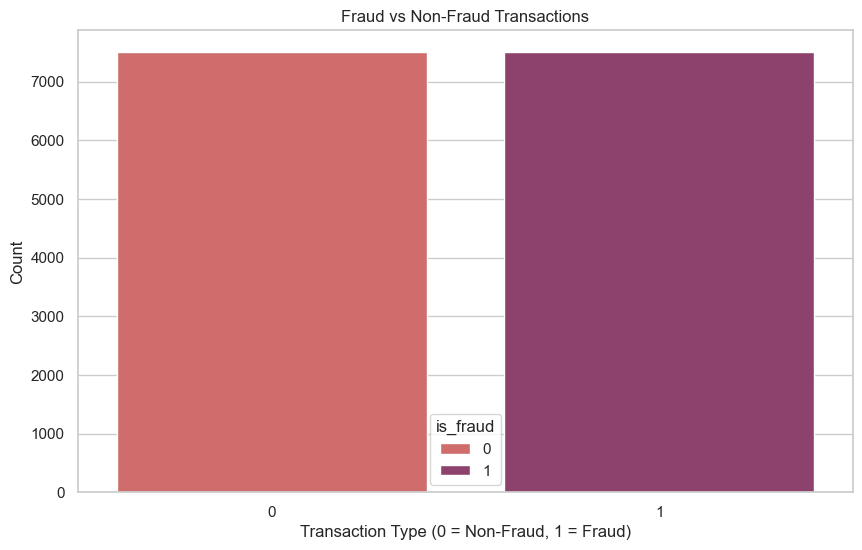

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=data['is_fraud'], hue=data["is_fraud"],palette="flare")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.savefig("./eda/1_fraud_vs_nonfraud.png")
plt.show()

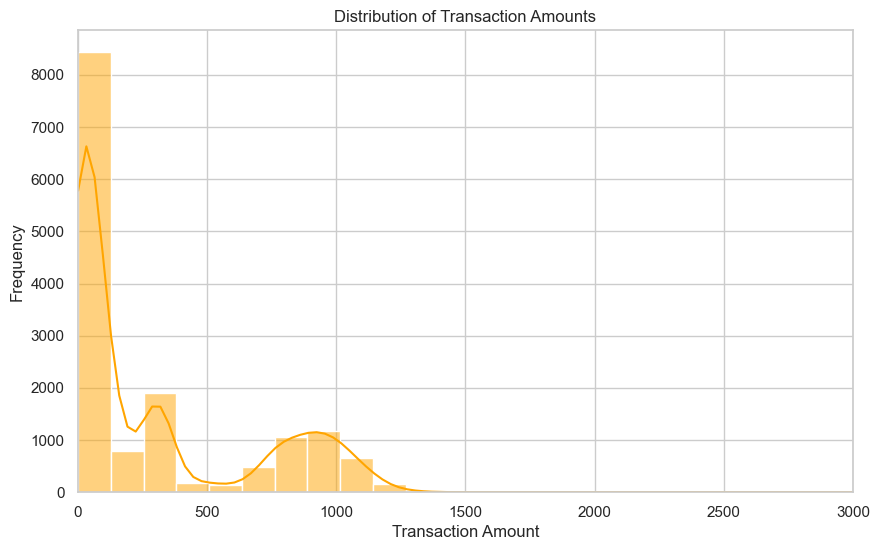

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data["amt"], bins=50, kde=True, color="orange")
plt.title("Distribution of Transaction Amounts")
plt.xlim(0, 3000)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.savefig("./eda/2_dist_trans_amount.png")
plt.show()

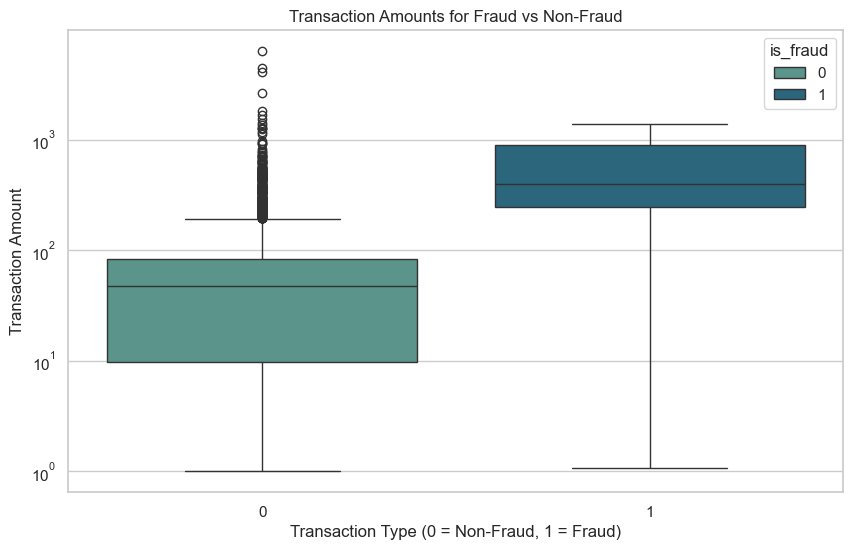

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="is_fraud", y="amt", data=data, hue="is_fraud",palette="crest")
plt.title("Transaction Amounts for Fraud vs Non-Fraud")
plt.xlabel("Transaction Type (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.yscale("log")  # Use log scale to handle skewed data
plt.savefig("./eda/3_amount_fraud_vs_nonfraud.png")
plt.show()

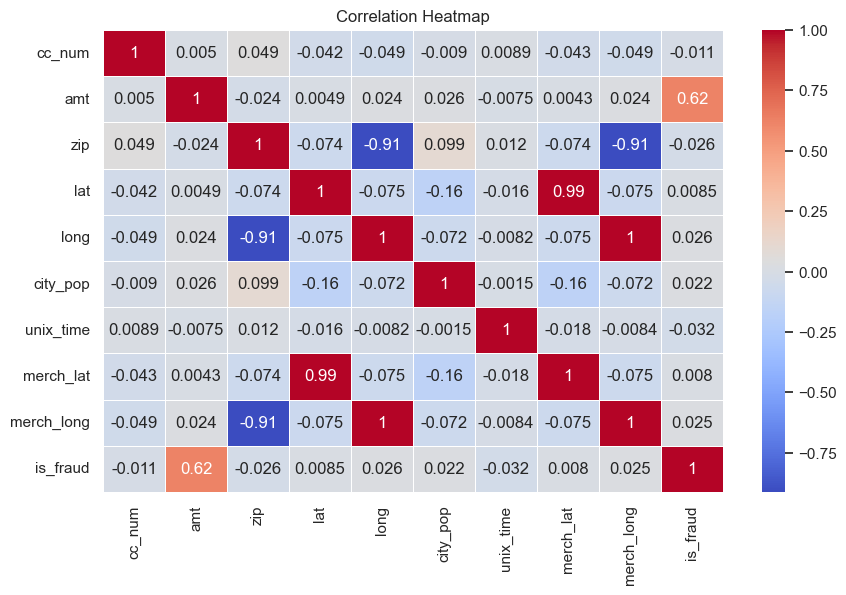

In [ ]:
df_numeric = data.select_dtypes(include=['number'])

# Generate the heatmap
plt.figure(figsize=(10, 6))
corr = df_numeric.corr()
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig("./eda/4_heatmap.png")
plt.show()

In [ ]:
len(data['category'].value_counts().to_dict().values())

14

In [ ]:
len(data['category'].unique().tolist())

14

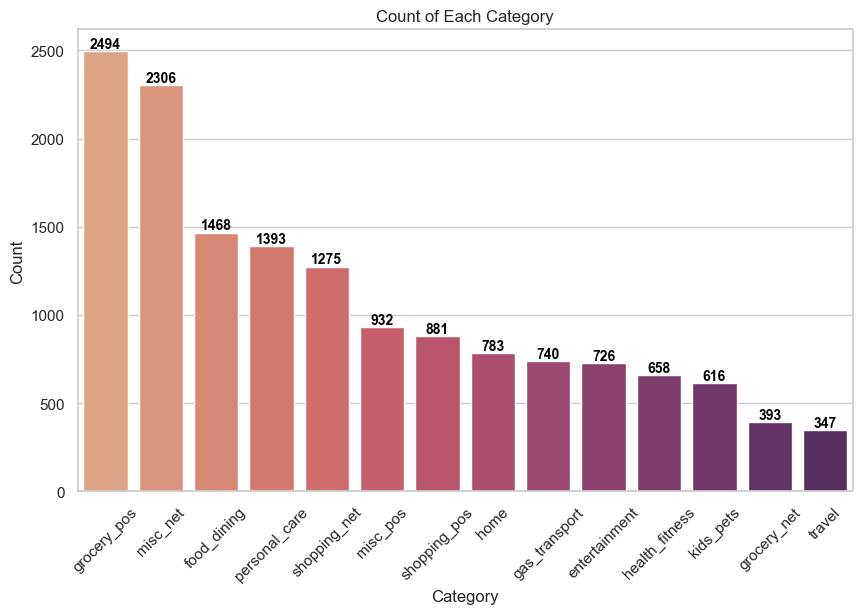

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=data['category'].unique().tolist(), y=data['category'].value_counts().to_dict().values(),
            hue=data['category'].unique().tolist(), palette="flare")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',   # format to 2 decimal places
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10, color='black', fontweight='bold'
    )

plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Count of Each Category")
plt.savefig("eda/5_category_count.png")
plt.show()

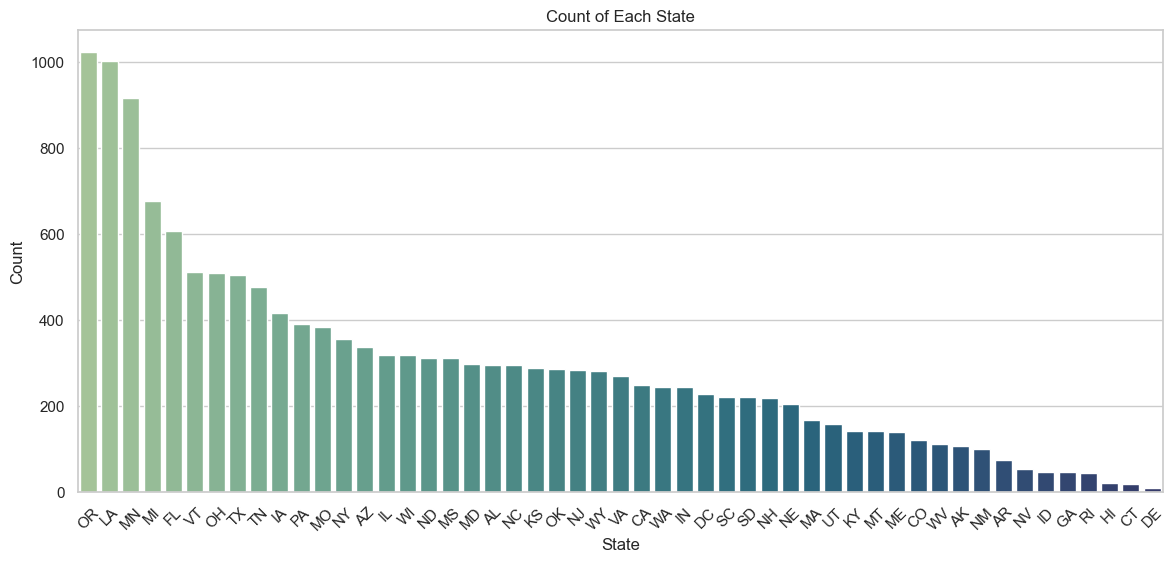

In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(x=data['state'].unique().tolist(), y=data['state'].value_counts().to_dict().values(),
            hue=data['state'].unique().tolist(), palette="crest")

plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Count of Each State")
plt.savefig("eda/6_state_count.png")
plt.show()

## **Dropping unwanted columns**

In [ ]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [ ]:
cols_to_keep = ['amt', 'category', 'unix_time', 'state', 'is_fraud']

data = data[cols_to_keep]

data.head()

,amt,category,unix_time,state,is_fraud
0,312.81,grocery_pos,1370048481,OR,1
1,909.75,misc_net,1347454181,LA,1
2,7.59,food_dining,1349456934,MN,0
3,3.41,food_dining,1346852048,MI,0
4,17.52,personal_care,1327273470,FL,1


In [ ]:
data['category'].unique()

array(['grocery_pos', 'misc_net', 'food_dining', 'personal_care',
       'shopping_net', 'misc_pos', 'shopping_pos', 'home',
       'gas_transport', 'entertainment', 'health_fitness', 'kids_pets',
       'grocery_net', 'travel'], dtype=object)

In [ ]:
data['state'].unique()

array(['OR', 'LA', 'MN', 'MI', 'FL', 'VT', 'OH', 'TX', 'TN', 'IA', 'PA',
       'MO', 'NY', 'AZ', 'IL', 'WI', 'ND', 'MS', 'MD', 'AL', 'NC', 'KS',
       'OK', 'NJ', 'WY', 'VA', 'CA', 'WA', 'IN', 'DC', 'SC', 'SD', 'NH',
       'NE', 'MA', 'UT', 'KY', 'MT', 'ME', 'CO', 'WV', 'AK', 'NM', 'AR',
       'NV', 'ID', 'GA', 'RI', 'HI', 'CT', 'DE'], dtype=object)

In [ ]:
data['hour'] = pd.to_datetime(data['unix_time'], unit='s').dt.hour
data['dayofweek'] = pd.to_datetime(data['unix_time'], unit='s').dt.dayofweek
data['is_weekend'] = data['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
data.drop('unix_time', axis=1, inplace=True)
data.head()

,amt,category,state,is_fraud,hour,dayofweek,is_weekend
0,312.81,grocery_pos,OR,1,1,5,1
1,909.75,misc_net,LA,1,12,2,0
2,7.59,food_dining,MN,0,17,4,0
3,3.41,food_dining,MI,0,13,2,0
4,17.52,personal_care,FL,1,23,6,1


## **Distribution**

In [ ]:
data[data['is_fraud'] ==1 ].head(10)

,amt,category,state,is_fraud,hour,dayofweek,is_weekend
0,312.81,grocery_pos,OR,1,1,5,1
1,909.75,misc_net,LA,1,12,2,0
4,17.52,personal_care,FL,1,23,6,1
5,877.46,shopping_net,VT,1,22,5,1
6,9.14,misc_pos,OH,1,23,4,0
8,999.84,shopping_net,OR,1,12,3,0
12,11.03,gas_transport,PA,1,3,3,0
16,272.15,grocery_pos,AZ,1,0,2,0
17,1090.93,shopping_net,MO,1,0,0,0
18,777.95,shopping_pos,IA,1,2,3,0


In [ ]:
data[data['is_fraud'] == 0].head(10)

,amt,category,state,is_fraud,hour,dayofweek,is_weekend
2,7.59,food_dining,MN,0,17,4,0
3,3.41,food_dining,MI,0,13,2,0
7,4.85,shopping_net,TX,0,11,0,0
9,1.65,shopping_pos,TX,0,5,0,0
10,47.08,home,TN,0,14,5,1
11,7.08,food_dining,IA,0,18,4,0
13,55.75,gas_transport,MO,0,11,3,0
14,51.81,entertainment,NY,0,21,3,0
15,41.22,gas_transport,OH,0,3,4,0
19,50.56,gas_transport,IL,0,0,3,0


## **Dependent and Independent Variables**

In [ ]:
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']


## **Encoding Categorical Features**

In [ ]:
import pickle

X = pd.get_dummies(X, columns=['category'], dtype=int)

# Extract only the one-hot encoded category columns (those starting with "category_")
saved_categories = [col for col in X.columns if col.startswith("category_")]

with open('saved_categories.pkl', 'wb') as f:
    pickle.dump(saved_categories, f)


In [ ]:
X = pd.get_dummies(X, columns=['state'], dtype=int)
saved_states = [col for col in X.columns if col.startswith("state_")]

with open('saved_states.pkl', 'wb') as f:
    pickle.dump(saved_states, f)


## **Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## **Preprocessing**

**Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.shape

(12009, 69)